# Neural Networks with PyTorch

In this notebook, we'll build and train two neural networks on the **MNIST** dataset — handwritten digit images (0–9), 28×28 pixels each. Our goal is to classify each image into one of the ten digit classes.

**What you'll do:**
1. Set up PyTorch and Colab (with a GPU)
2. Download MNIST and look at a few examples
3. Build and train a **Multilayer Perceptron (MLP)** — the "stacked logistic regressions" idea from the slides
4. Build and train a **Convolutional Neural Network (CNN)** — same task, designed for images
5. Compare the two: which is more accurate? Which uses fewer parameters?

By the end, you'll have written two real neural networks in PyTorch — and seen first-hand why CNNs dominate computer vision.

## 1. Why Google Colab?

Two reasons we're running this in Colab instead of locally:

1. **No environment setup.** Installing PyTorch on your own machine can get complicated — versions of Python, CUDA (NVIDIA's GPU library), and PyTorch all have to line up. Different operating systems (Mac/Windows/Linux) make this harder. Colab gives everyone the same pre-built environment.

2. **Free GPUs.** Neural networks train ~10–100× faster on a GPU than a CPU. While your dev computers are certainly capable of this task, Colab lets you borrow one for free.

### Turning on the GPU

Before you run any cells:

1. In the Colab menu, click **`Runtime` → `Change runtime type`**.
2. Under **`Hardware accelerator`**, choose **`T4 GPU`** (or any GPU option).
3. Click **`Save`**.

The setup cells below will confirm that PyTorch can see the GPU. If you see `Using device: cuda`, you're set.

## 2. Setup

PyTorch and torchvision (which gives us the MNIST dataset) are both pre-installed in Colab. We just need to import them.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import pandas as pd

# Pick GPU if available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [2]:
!nvidia-smi

Tue Jun  2 19:32:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3. Load MNIST

MNIST is a classic dataset of 70,000 handwritten digit images, split into 60,000 training images and 10,000 test images. Each image is 28×28 pixels and grayscale.

`torchvision` downloads it directly from the internet on first use — no hosting needed.

We apply two transformations to every image:
- **`ToTensor`** — converts the image to a PyTorch tensor with pixel values in `[0, 1]`.
- **`Normalize`** — rescales pixel values to have mean ≈ 0, std ≈ 1 (standard practice; helps the network train).

**Train / validation / test split.** From the slides: a model is trained on the **training set**, hyperparameters (like the number of epochs) are tuned on the **validation set**, and the **test set** is held out until the very end as an honest measure of final performance. We'll carve 10K validation images out of the 60K training set and leave the 10K test set strictly off-limits during training.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),   # midpoint of [0,1] and half-range
])

# Download MNIST: 60K training images + 10K test images
train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Carve 10K validation images out of the 60K training set.
# Train  - fits the model
# Val    - used during training to track overfitting and pick the epoch count
# Test   - held out; only used at the very end for the final accuracy
train_split, val_split = random_split(
    train_data, [50_000, 10_000],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_split, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_split,   batch_size=1000)
test_loader  = DataLoader(test_data,   batch_size=1000)

print(f"Training images:   {len(train_split)}")
print(f"Validation images: {len(val_split)}")
print(f"Test images:       {len(test_data)}")
print(f"Image shape:       {train_data[0][0].shape}  (channels, height, width)")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]

Training images:   50000
Validation images: 10000
Test images:       10000
Image shape:       torch.Size([1, 28, 28])  (channels, height, width)


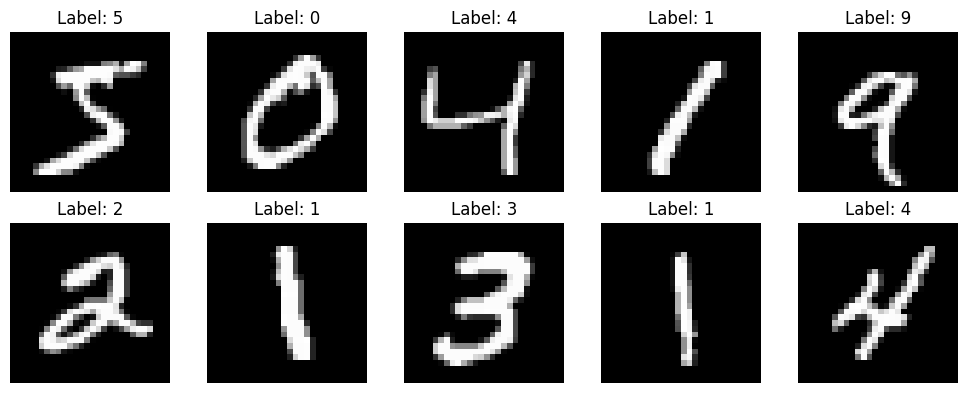

In [4]:
# Show a grid of training images with their labels
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, (img, label) in zip(axes.flatten(), train_data):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Training utilities

Training any PyTorch model follows the same pattern: loop over the data, make predictions, compute the loss, and update the weights. We'll write a few helpers we can reuse for both models.

- **`train_one_epoch`** runs one full pass over the training data and returns the average loss.
- **`evaluate`** runs the model on a given dataset and returns accuracy.
- **`train_with_history`** trains for N epochs, records per-epoch metrics, and **keeps the model state from the best validation epoch** so we don't end up reporting overfit final weights.

In [5]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()           # reset gradients
        out = model(x)                  # forward pass
        loss = criterion(out, y)        # compute loss
        loss.backward()                 # backprop — compute gradients
        optimizer.step()                # update weights

        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total


def train_with_history(model, train_loader, val_loader, optimizer, criterion, device, epochs):
    """Train for `epochs` epochs. Records per-epoch metrics and keeps the
    model state from the best validation epoch (so we don't end up with
    overfit weights at the final epoch)."""
    history = {'train_loss': [], 'val_acc': []}
    best_acc = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_acc    = evaluate(model, val_loader, device)
        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)

        # If this epoch's validation accuracy is the best so far, snapshot the weights
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            marker = "  - new best"
        else:
            marker = ""

        print(f"Epoch {epoch:2d}: train_loss={train_loss:.4f}, val_acc={val_acc:.4f}{marker}")

    # Restore the best-validation weights before returning
    model.load_state_dict(best_state)
    print(f"\nRestored best model (val_acc={best_acc:.4f})")
    return history


def count_params(model):
    return sum(p.numel() for p in model.parameters())

## 5. Model 1 — Multilayer Perceptron (MLP)

An MLP (also called a feed-forward network or FFNN) is the simplest neural network: layers of neurons connected to every neuron in the next layer.

From the slides: **"Logistic regression is one neuron. Stack them and you get a neural network."** This is that idea, made concrete.

**Architecture:**
- Flatten the 28×28 image into a 784-long vector
- Fully-connected layer: 784 → 256, ReLU activation
- Fully-connected layer: 256 → 128, ReLU
- Output layer:          128 → 10 (one score per digit class)

In [6]:
mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
).to(device)

print(mlp)
print(f"\nTotal parameters: {count_params(mlp):,}")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 235,146


In [7]:
EPOCHS = 10

optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

mlp_history = train_with_history(mlp, train_loader, val_loader, optimizer, criterion, device, epochs=EPOCHS)

mlp_params = count_params(mlp)

Epoch  1: train_loss=0.4226, val_acc=0.9266  - new best
Epoch  2: train_loss=0.1958, val_acc=0.9506  - new best
Epoch  3: train_loss=0.1365, val_acc=0.9580  - new best
Epoch  4: train_loss=0.1055, val_acc=0.9649  - new best
Epoch  5: train_loss=0.0909, val_acc=0.9509
Epoch  6: train_loss=0.0727, val_acc=0.9625
Epoch  7: train_loss=0.0667, val_acc=0.9695  - new best
Epoch  8: train_loss=0.0543, val_acc=0.9702  - new best
Epoch  9: train_loss=0.0492, val_acc=0.9723  - new best
Epoch 10: train_loss=0.0456, val_acc=0.9670

Restored best model (val_acc=0.9723)


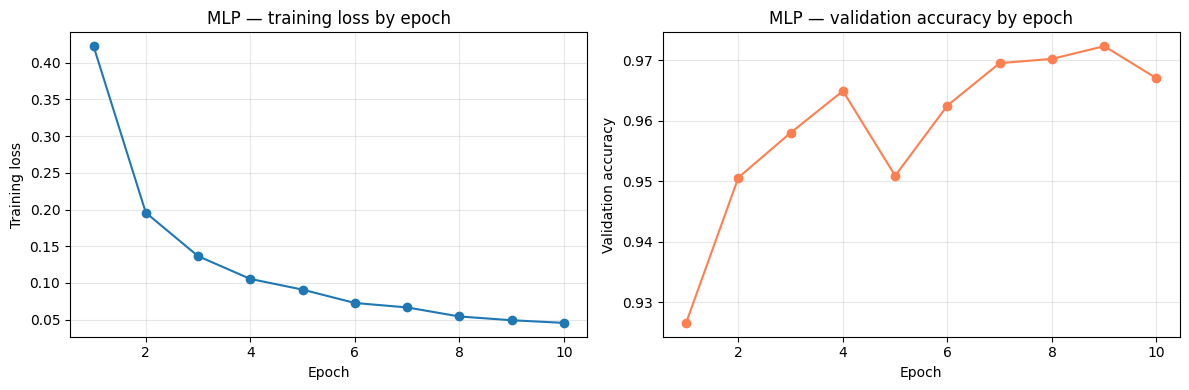

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, mlp_history['train_loss'], marker='o')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Training loss')
axes[0].set_title('MLP — training loss by epoch')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, mlp_history['val_acc'], marker='o', color='coral')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation accuracy')
axes[1].set_title('MLP — validation accuracy by epoch')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Reading the curves:**
- Training loss drops steadily as the network fits the training data better.
- Validation accuracy usually climbs early, then plateaus (or even dips). That dip is **overfitting** — the same picture we saw with decision tree depth in the first notebook, just on a neural network this time.
- The "best" number of epochs is wherever validation accuracy peaks or stops improving. We could **early-stop** at that point rather than running the full 10 epochs.

## 6. Model 2 — Convolutional Neural Network (CNN)

An MLP treats every pixel independently — it has no concept that nearby pixels are related, or that a `7` looks like a `7` no matter where it sits in the image.

A **CNN** fixes this with **convolutional layers** that scan small patches of the image, sharing the same weights across all positions. This makes them dramatically more efficient for images.

**Architecture:**
- Convolution: 1 channel → 16 channels, 3×3 filter, ReLU
- Max-pool 2×2 (halves the height & width)
- Convolution: 16 → 32 channels, 3×3 filter, ReLU
- Max-pool 2×2
- Flatten and a final dense layer → 10 classes

Watch the parameter count compared to the MLP.

In [9]:
cnn = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32*7* 7, 10),
).to(device)

print(cnn)
print(f"\nTotal parameters: {count_params(cnn):,}")

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1568, out_features=10, bias=True)
)

Total parameters: 20,490


In [10]:
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

cnn_history = train_with_history(cnn, train_loader, val_loader, optimizer, criterion, device, epochs=EPOCHS)

cnn_params = count_params(cnn)

Epoch  1: train_loss=0.3210, val_acc=0.9688  - new best
Epoch  2: train_loss=0.0764, val_acc=0.9783  - new best
Epoch  3: train_loss=0.0552, val_acc=0.9815  - new best
Epoch  4: train_loss=0.0468, val_acc=0.9839  - new best
Epoch  5: train_loss=0.0398, val_acc=0.9839
Epoch  6: train_loss=0.0338, val_acc=0.9852  - new best
Epoch  7: train_loss=0.0297, val_acc=0.9832
Epoch  8: train_loss=0.0248, val_acc=0.9848
Epoch  9: train_loss=0.0224, val_acc=0.9849
Epoch 10: train_loss=0.0202, val_acc=0.9863  - new best

Restored best model (val_acc=0.9863)


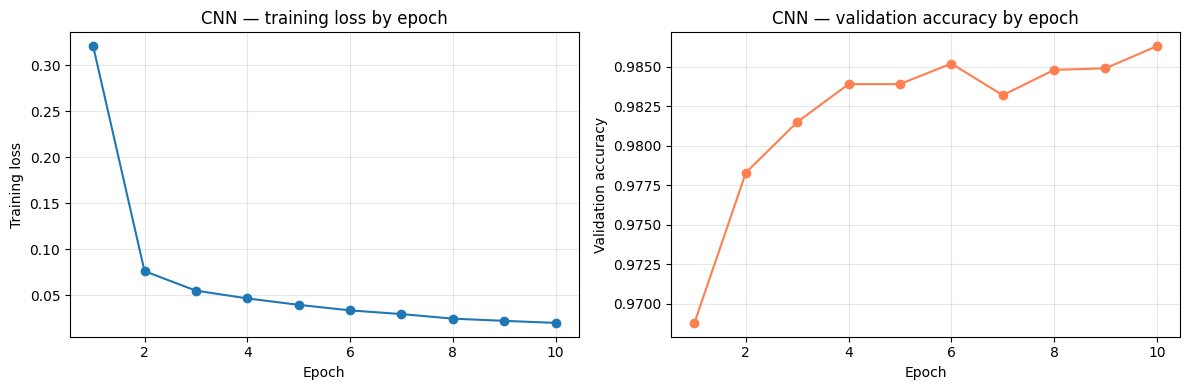

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, cnn_history['train_loss'], marker='o')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Training loss')
axes[0].set_title('CNN — training loss by epoch')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, cnn_history['val_acc'], marker='o', color='coral')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation accuracy')
axes[1].set_title('CNN — validation accuracy by epoch')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Compare MLP vs. CNN

At this point we've trained and tuned using the training and validation sets. For the final, honest comparison, we evaluate both models on the **held-out test set** — images neither network has ever seen.

Model  Test accuracy  Parameters
  MLP         0.9738      235146
  CNN         0.9881       20490


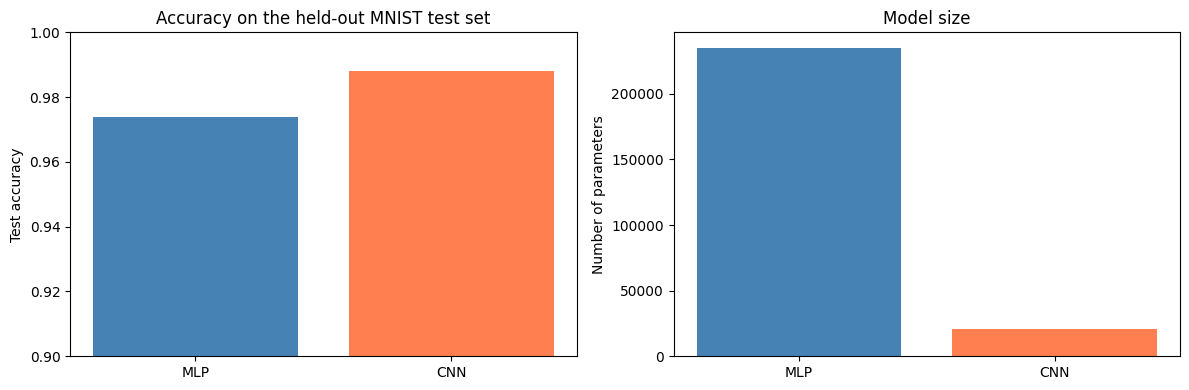

In [12]:
# Evaluate on the held-out test set — neither model has seen these images
mlp_acc = evaluate(mlp, test_loader, device)
cnn_acc = evaluate(cnn, test_loader, device)

results = pd.DataFrame({
    'Model':         ['MLP', 'CNN'],
    'Test accuracy': [mlp_acc, cnn_acc],
    'Parameters':    [mlp_params, cnn_params],
})

print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(results['Model'], results['Test accuracy'], color=['steelblue', 'coral'])
axes[0].set_ylim(0.9, 1.0)
axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Accuracy on the held-out MNIST test set')

axes[1].bar(results['Model'], results['Parameters'], color=['steelblue', 'coral'])
axes[1].set_ylabel('Number of parameters')
axes[1].set_title('Model size')

plt.tight_layout()
plt.show()

## 8. Reflection

A few things to take away:

- **The CNN beats the MLP with far fewer parameters.** That's not an accident — convolutional layers exploit the fact that nearby pixels in an image are related, which lets them share weights across positions. The MLP has to learn each pixel position independently.
- **The MLP is surprisingly close on MNIST.** Don't read too much into the small gap here. MNIST is an *easy* problem: small, grayscale, centered digits with clean backgrounds. On harder data — higher-resolution color photos (CIFAR, ImageNet), medical scans, satellite imagery — the MLP falls dramatically behind. The CNN's spatial-structure advantage only matters *more*, not less, as problems get real.
- **Same training loop, different model.** Once you've written `train_one_epoch` and `evaluate`, swapping models is one block of code. The PyTorch workflow generalizes.
- **This is the simplest possible CNN.** Real production CNNs (ResNet, EfficientNet, etc.) have tens to hundreds of layers and millions of parameters. The architectural ideas — convolutions, pooling, depth — are exactly the same.